In [1]:
%load_ext autoreload
%autoreload 2

import os
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

from scipy.stats import norm, lognorm, gaussian_kde, beta, weibull_min, triang, expon, pareto

sns.set(style="whitegrid", font_scale=1.2)
np.random.seed(42)
title_font = 18
labels_font = 16
text_font = 14
tick_font = 12
images_dir = "images/distributions_for_ml"
os.makedirs(images_dir, exist_ok=True)

# Distributions for Machine Learning: The Art of Asking Questions

This notebook supports [this](https://afnan-sultan.github.io/posts/2025/10/distributions_ml_questions/) blog post by plotting the different plots shown in it.

This notebook guides one through:

1. Plotting different distribution shape
2. Inspecting how distribution shape influences the sample size needed for truthful representation
3. How to reverse engineer the answer to the question: Is this a randomly drawn sample?
    - Statistically
    - Chemically

TL;DR
![image](images/distributions_for_ml/flowchart.png)

---

# The normal (Gaussian) distribution

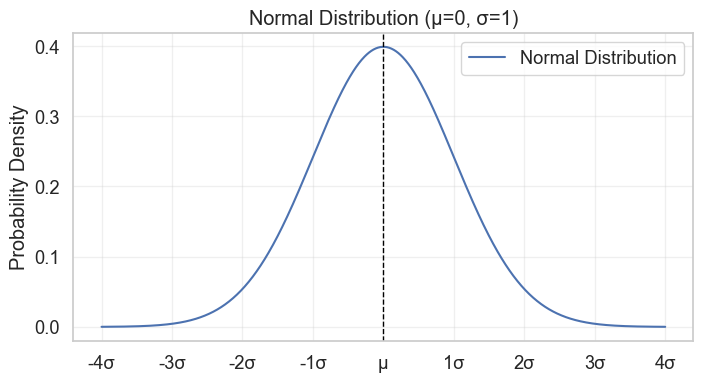

In [2]:
# Parameters
mu = 0      # mean
sigma = 1   # standard deviation

# X values from -4σ to +4σ
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, y, label="Normal Distribution")
plt.title("Normal Distribution (μ=0, σ=1)")
plt.ylabel("Probability Density")

# Custom x-ticks in terms of sigma
xticks = np.arange(-4, 5)  # -4σ to +4σ
plt.xticks(xticks, [f"{i}σ" if i != 0 else "μ" for i in xticks])

plt.axvline(mu, color="black", linestyle="--", linewidth=1)
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(os.path.join(images_dir, "gaussian.png"))
plt.show()


# The bi(multi)modal distribution

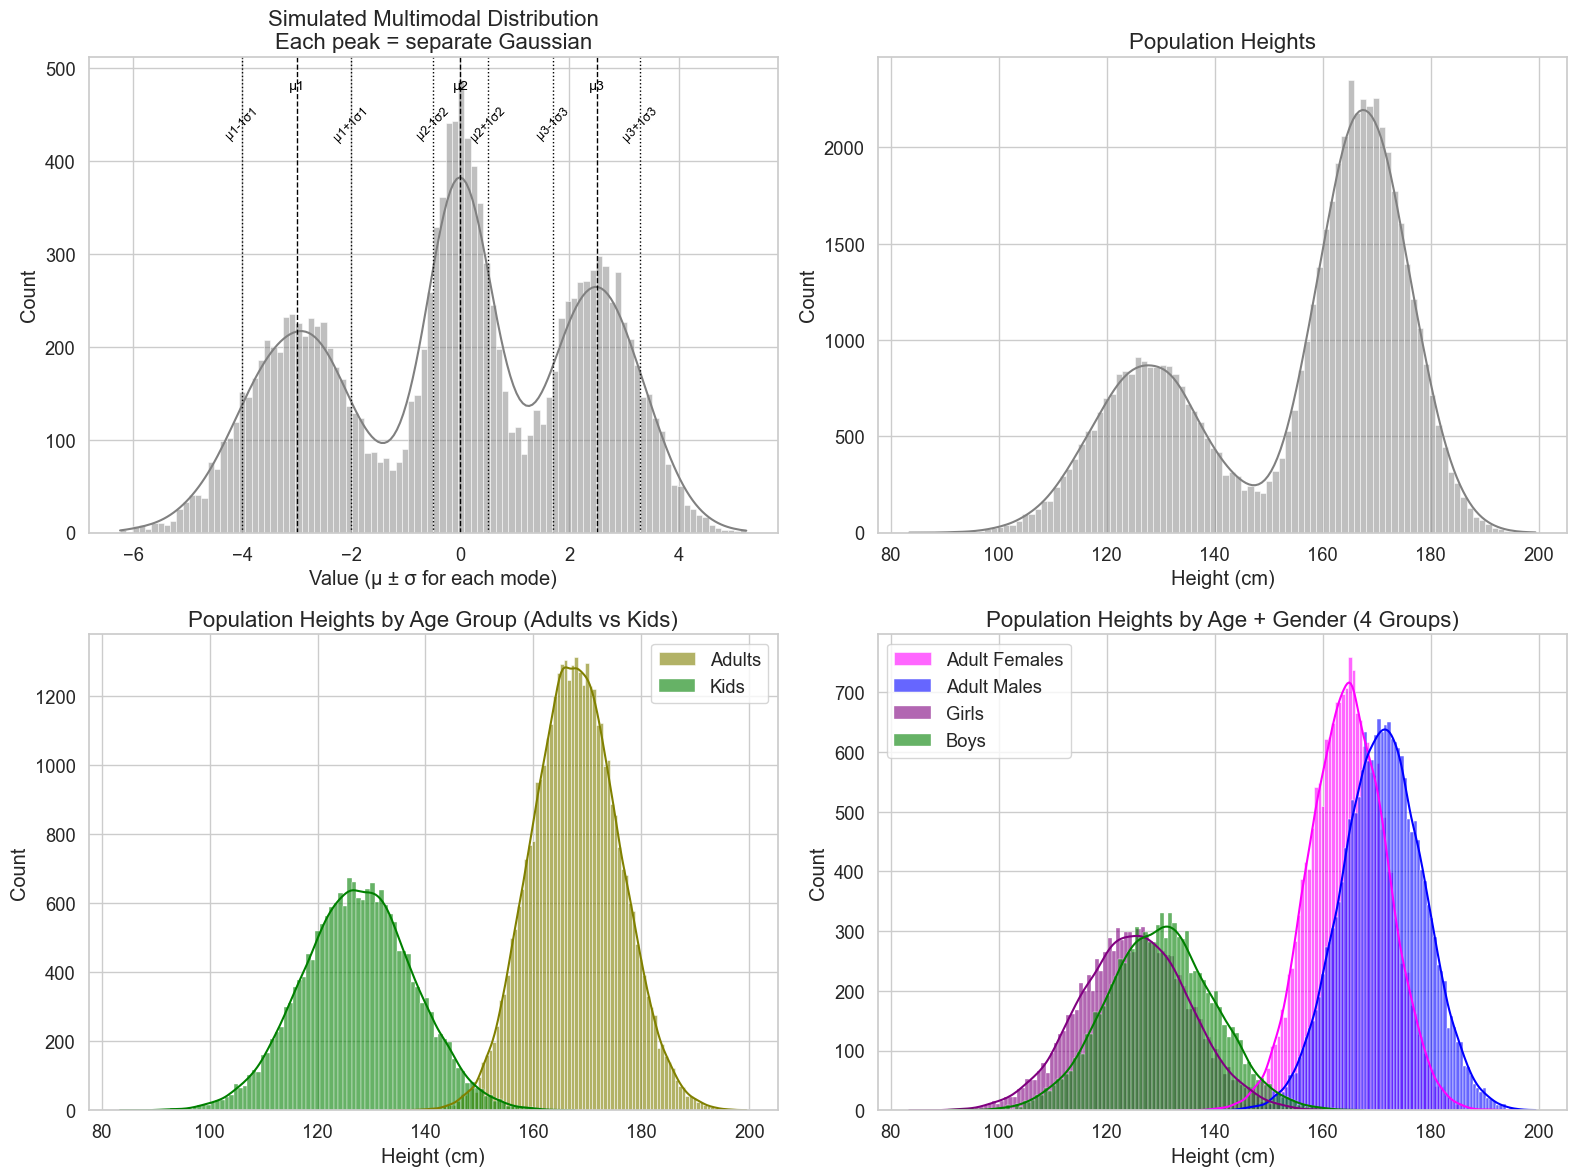

In [3]:
np.random.seed(42)

# ---------- Panel 1: Simulated multimodal ----------
modes = [
    {"mu": -3, "sigma": 1, "size": 5000},
    {"mu": 0,  "sigma": 0.5, "size": 5000},
    {"mu": 2.5, "sigma": 0.8, "size": 5000}
]

simulated_modes = [np.random.normal(loc=m["mu"], scale=m["sigma"], size=m["size"]) for m in modes]
simulated_multimodal = np.concatenate(simulated_modes)

# ---------- Height Distributions (consistent for panels 2–4) ----------
n = 20_000

# Adult females
female_mean, female_std = 164.7, 7.07
female_heights = np.random.normal(loc=female_mean, scale=female_std, size=n)

# Adult males
male_mean, male_std = 171.0, 7.59
male_heights = np.random.normal(loc=male_mean, scale=male_std, size=n)

# Kids
kid_female_mean, kid_female_std = 125, 10
kid_male_mean, kid_male_std = 130, 10

kid_female_heights = np.random.normal(loc=kid_female_mean, scale=kid_female_std, size=n // 2)
kid_male_heights = np.random.normal(loc=kid_male_mean, scale=kid_male_std, size=n // 2)

# Combine once and reuse
kids_heights = np.concatenate([kid_female_heights, kid_male_heights])
adults_heights = np.concatenate([female_heights, male_heights])
all_heights = np.concatenate([adults_heights, kids_heights])

# ---------- Plotting ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
title_fontsize = 16

# --- Panel 1: Simulated multimodal w/ annotated σ ---
ax = axes[0, 0]
sns.histplot(simulated_multimodal, bins=100, kde=True, ax=ax, color="gray")

for i, m in enumerate(modes):
    mu, sigma = m["mu"], m["sigma"]
    ax.axvline(mu, color="black", linestyle="--", linewidth=1)
    ax.text(mu, ax.get_ylim()[1]*0.95, f"μ{i+1}", ha="center", va="top", fontsize=10, color="black")

    for s in [-1, 1]:
        x = mu + s * sigma
        ax.axvline(x, color="black", linestyle=":", linewidth=1)
        ax.text(x, ax.get_ylim()[1]*0.9, f"μ{i+1}{'+' if s > 0 else '-'}1σ{i+1}",
                ha="center", va="top", fontsize=9, color="black", rotation=45)

ax.set_title("Simulated Multimodal Distribution\nEach peak = separate Gaussian", fontsize=title_fontsize)
ax.set_xlabel("Value (μ ± σ for each mode)")

# --- Panel 2: Height - All combined, no color ---
ax = axes[0, 1]
sns.histplot(all_heights, bins=100, kde=True, ax=ax, color="gray")
ax.set_title("Population Heights", fontsize=title_fontsize)
ax.set_xlabel("Height (cm)")

# --- Panel 3: Height - 2 groups (Adults vs Kids only) ---
ax = axes[1, 0]
sns.histplot(adults_heights, bins=100, kde=True, ax=ax, color="olive", label="Adults", alpha=0.6)
sns.histplot(kids_heights, bins=100, kde=True, ax=ax, color="green", label="Kids", alpha=0.6)
ax.set_title("Population Heights by Age Group (Adults vs Kids)", fontsize=title_fontsize)
ax.set_xlabel("Height (cm)")
ax.legend()


# --- Panel 4: Height - 4 groups (Adults + Kids by gender) ---
ax = axes[1, 1]
sns.histplot(female_heights, bins=100, kde=True, ax=ax, color="magenta", label="Adult Females", alpha=0.6)
sns.histplot(male_heights, bins=100, kde=True, ax=ax, color="blue", label="Adult Males", alpha=0.6)
sns.histplot(kid_female_heights, bins=100, kde=True, ax=ax, color="purple", label="Girls", alpha=0.6)
sns.histplot(kid_male_heights, bins=100, kde=True, ax=ax, color="green", label="Boys", alpha=0.6)
ax.set_title("Population Heights by Age + Gender (4 Groups)", fontsize=title_fontsize)
ax.set_xlabel("Height (cm)")
ax.legend()

# Final touches
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "multimodal.png"))
plt.show()


# The lognormal distribution

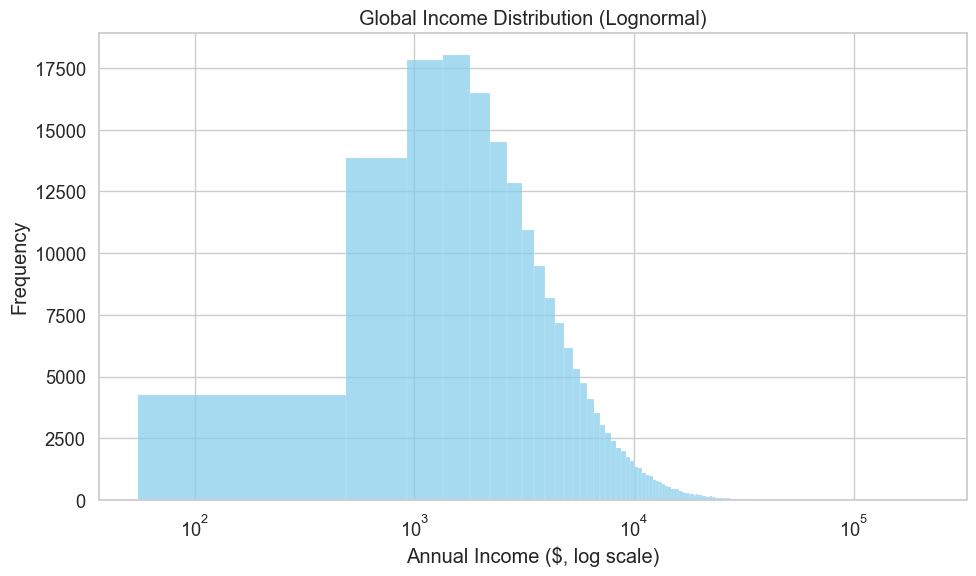

In [4]:
np.random.seed(40)

# --- Lognormal income distribution parameters ---
population = 200_000
share_lognormal = 0.95
n_lognormal = int(population * share_lognormal)

mu, sigma = 8.0, 0.9  # Parameters for lognormal (mean and std of log)

# Generate lognormal income data
lognormal_incomes = np.random.lognormal(mean=mu, sigma=sigma, size=n_lognormal)

# Plotting
plt.figure(figsize=(10, 6))
sns.histplot(lognormal_incomes, bins=500, color="skyblue")
plt.xscale("log")  # Use log scale for better visibility
plt.xlabel("Annual Income ($, log scale)")
plt.ylabel("Frequency")
plt.title("Global Income Distribution (Lognormal)")
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "lognormal.png"))
plt.show()


# The uniform distribution

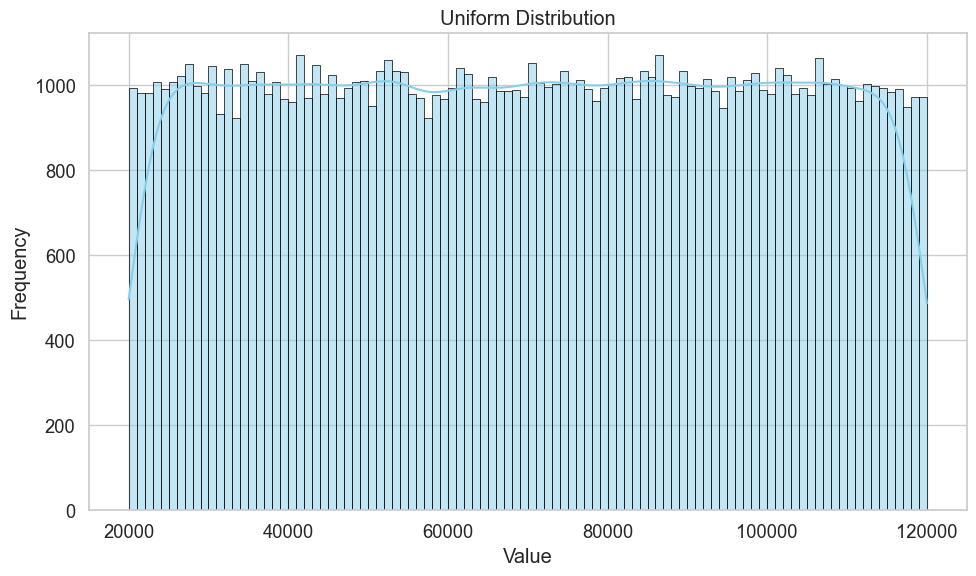

In [5]:
np.random.seed(42)

# --- Uniform distribution parameters ---
low = 20_000    # minimum income (or value)
high = 120_000  # maximum income (or value)
n_samples = 100_000

# Generate uniform data
uniform_data = np.random.uniform(low=low, high=high, size=n_samples)

# Plotting
plt.figure(figsize=(10, 6))
sns.histplot(uniform_data, bins=100, kde=True, color="skyblue", edgecolor="black")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Uniform Distribution")
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "uniform.png"))
plt.show()


# Skewed distributions

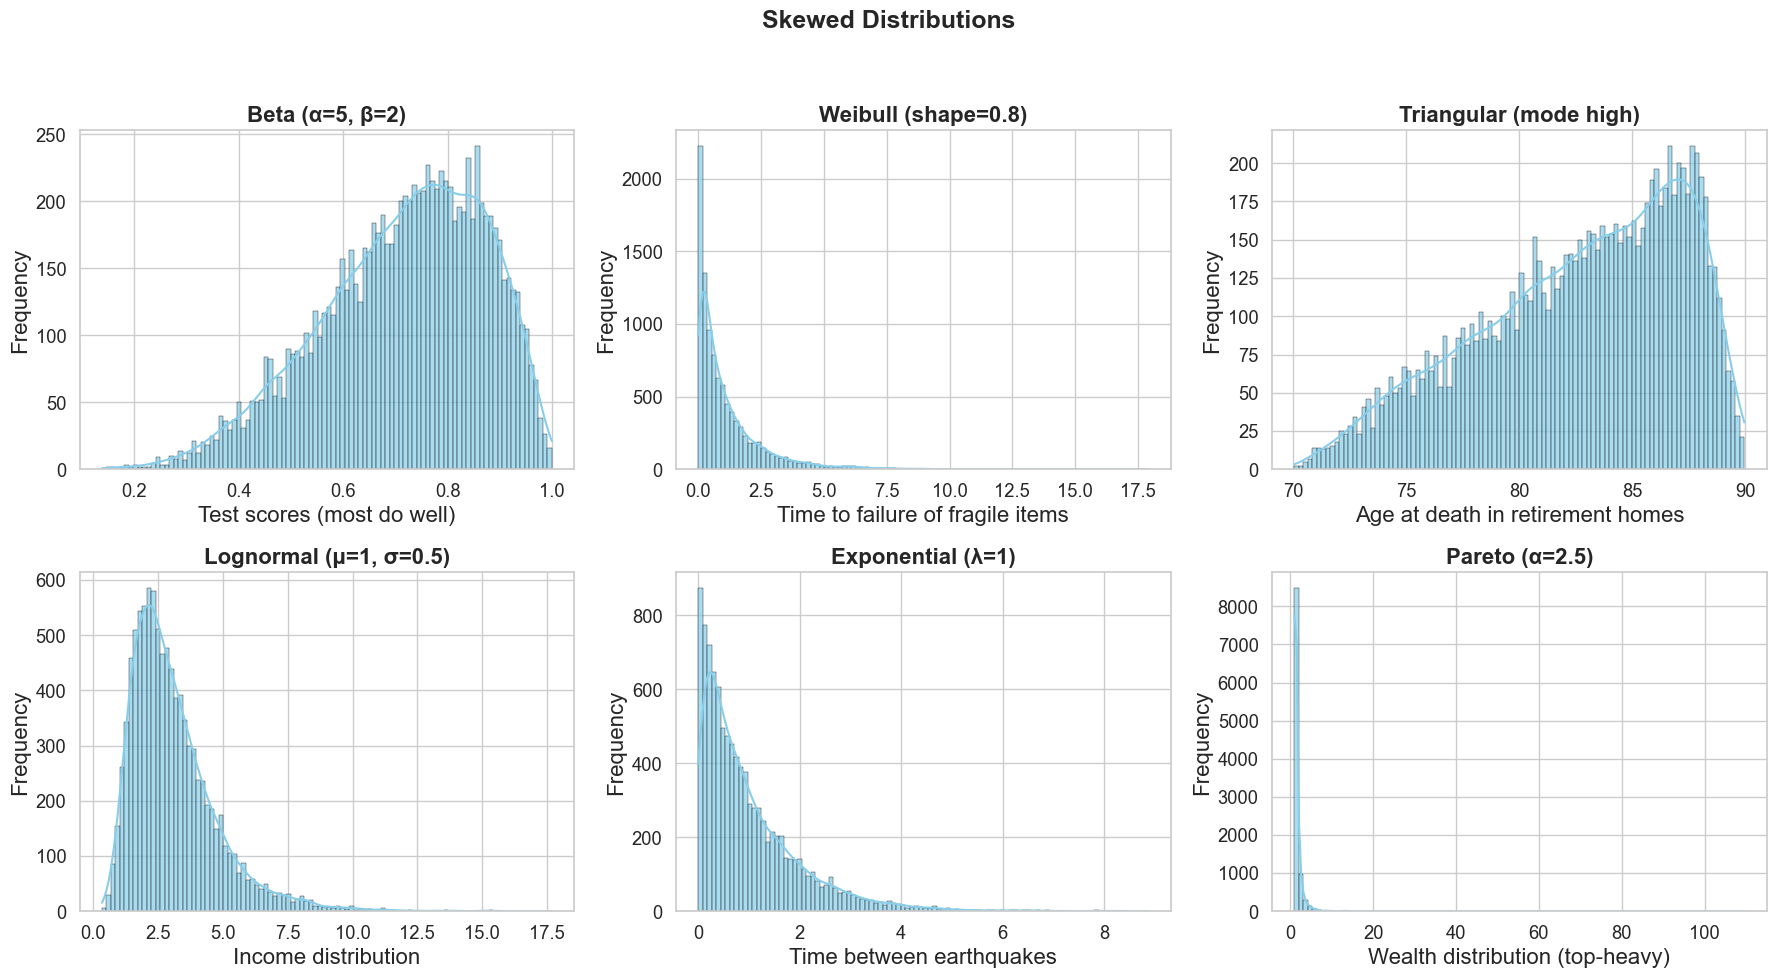

In [6]:
np.random.seed(42)

# --- Distributions & Sources ---
distributions = [
    # Left-skewed
    {
        "name": "Beta (α=5, β=2)",
        "data": beta.rvs(a=5, b=2, size=10000),
        "example": "Test scores (most do well)"
    },
    {
        "name": "Weibull (shape=0.8)",
        "data": weibull_min.rvs(c=0.8, size=10000),
        "example": "Time to failure of fragile items"
    },
    {
        "name": "Triangular (mode high)",
        "data": triang.rvs(c=0.9, loc=70, scale=20, size=10000),
        "example": "Age at death in retirement homes"
    },

    # Right-skewed
    {
        "name": "Lognormal (μ=1, σ=0.5)",
        "data": np.random.lognormal(mean=1, sigma=0.5, size=10000),
        "example": "Income distribution"
    },
    {
        "name": "Exponential (λ=1)",
        "data": expon.rvs(scale=1, size=10000),
        "example": "Time between earthquakes"
    },
    {
        "name": "Pareto (α=2.5)",
        "data": pareto.rvs(b=2.5, scale=1, size=10000),
        "example": "Wealth distribution (top-heavy)"
    },
]

# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, dist in zip(axes, distributions):
    sns.histplot(dist["data"], bins=100, kde=True, ax=ax, color="skyblue", edgecolor="black", alpha=0.7)
    ax.set_title(dist["name"], fontsize=16, weight="bold")
    ax.set_xlabel(dist["example"], fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)

plt.suptitle("Skewed Distributions", fontsize=18, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(images_dir, "skewed.png"))
plt.show()


# Distribution shape influences the sample size needed for truthful representation

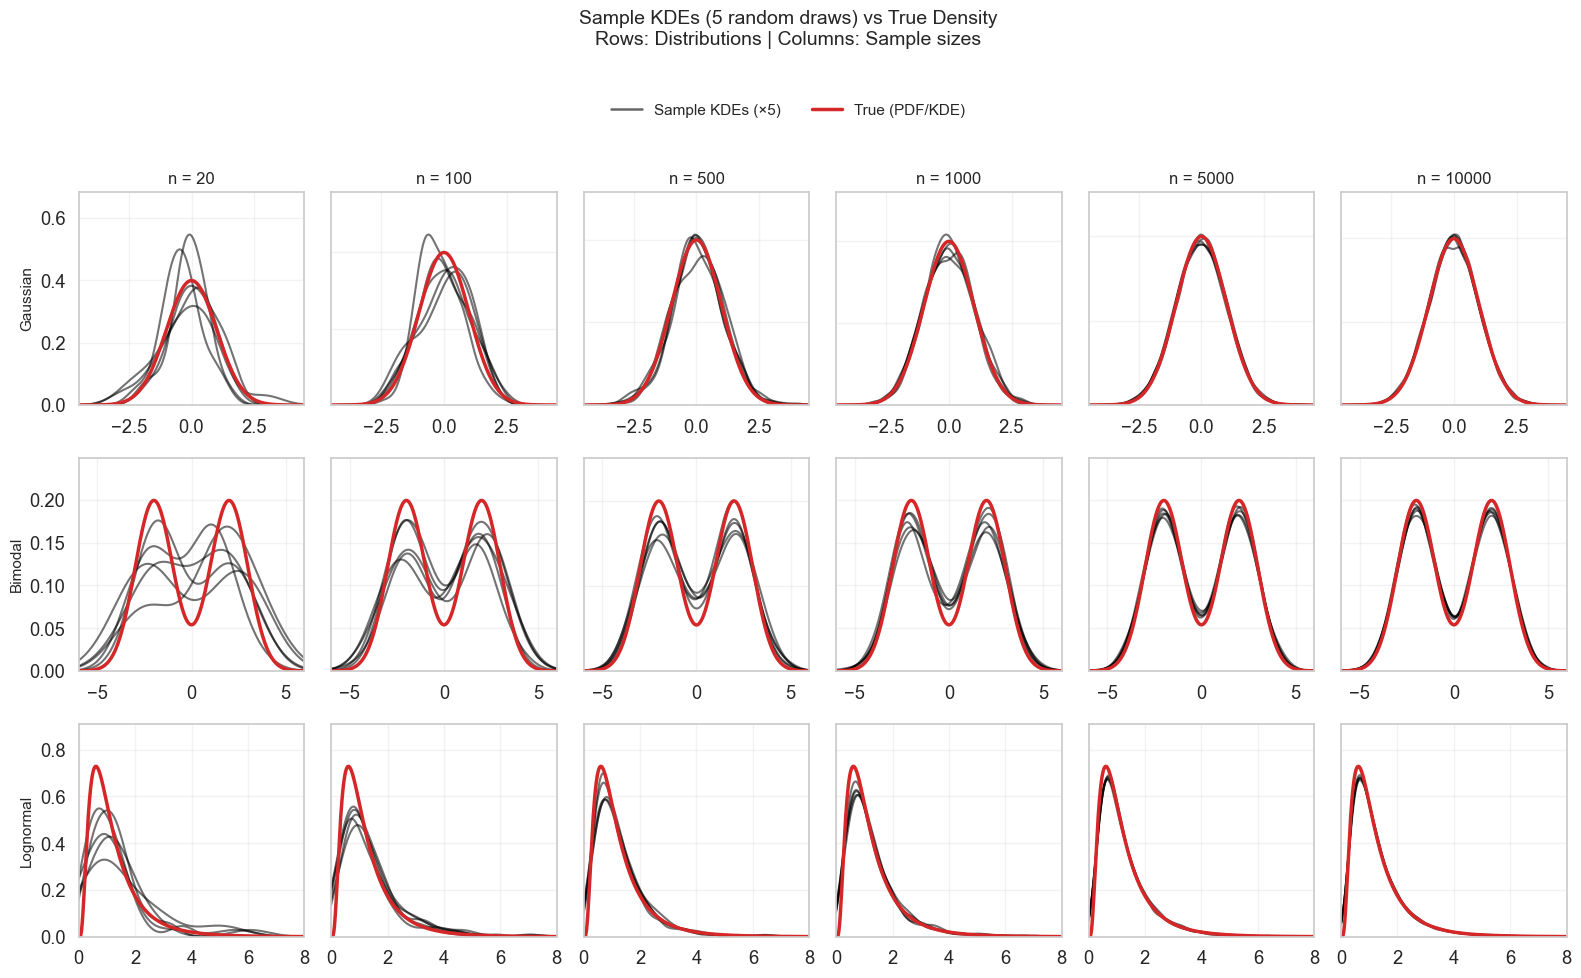

In [7]:
# -----------------------
# Helpers: sampling & true densities
# -----------------------

def sample_normal(rng, n, mu=0.0, sigma=1.0):
    return rng.normal(mu, sigma, size=n)

def pdf_normal(x, mu=0.0, sigma=1.0):
    return norm.pdf(x, loc=mu, scale=sigma)

def sample_mixture(rng, n, weights=(0.5, 0.5), mus=(-2.0, 2.0), sigmas=(1.0, 1.0)):
    comps = rng.choice(len(weights), size=n, p=weights)
    out = np.empty(n)
    for k in range(len(weights)):
        idx = comps == k
        out[idx] = rng.normal(mus[k], sigmas[k], size=idx.sum())
    return out

def pdf_mixture(x, weights=(0.5, 0.5), mus=(-2.0, 2.0), sigmas=(1.0, 1.0)):
    total = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, mus, sigmas):
        total += w * norm.pdf(x, loc=m, scale=s)
    return total

def sample_lognormal(rng, n, mu=0.0, sigma=0.7):
    return rng.lognormal(mean=mu, sigma=sigma, size=n)

def pdf_lognormal(x, mu=0.0, sigma=0.7):
    return lognorm.pdf(x, s=sigma, scale=np.exp(mu))

def sample_uniform(rng, n, a=-3.0, b=3.0):
    return rng.uniform(a, b, size=n)

# --- NEW: analytic Gaussian-kernel KDE of a Uniform(a,b) ---
def true_uniform_kde(x, a=-3.0, b=3.0, h=0.25):
    # Convolution of uniform density with N(0, h^2) kernel:
    # (1/(b-a)) * [Phi((x-a)/h) - Phi((x-b)/h)]
    return (norm.cdf((x - a) / h) - norm.cdf((x - b) / h)) / (b - a)

# -----------------------
# Configuration
# -----------------------

sample_sizes = [20, 100, 500, 1000, 5000, 10000]
n_reps = 5  # number of random seeds/samples per size
base_seed = 2025

rows = [
    {
        "name": "Gaussian",
        "sampler": lambda rng, n: sample_normal(rng, n, 0.0, 1.0),
        "true_pdf": lambda x: pdf_normal(x, 0.0, 1.0),
        "xlim": (-4.5, 4.5),
        "xgrid": np.linspace(-4.5, 4.5, 1500),
    },
    {
        "name": "Bimodal",
        "sampler": lambda rng, n: sample_mixture(rng, n, weights=(0.5, 0.5), mus=(-2.0, 2.0), sigmas=(1.0, 1.0)),
        "true_pdf": lambda x: pdf_mixture(x, weights=(0.5, 0.5), mus=(-2.0, 2.0), sigmas=(1.0, 1.0)),
        "xlim": (-6.0, 6.0),
        "xgrid": np.linspace(-6.0, 6.0, 1500),
    },
    {
        "name": "Lognormal",
        "sampler": lambda rng, n: sample_lognormal(rng, n, mu=0.0, sigma=0.7),
        "true_pdf": lambda x: pdf_lognormal(x, mu=0.0, sigma=0.7),
        "xlim": (0.0, 8.0),
        "xgrid": np.linspace(1e-6, 8.0, 1500),
    },
]

# -----------------------
# Plotting
# -----------------------

fig, axes = plt.subplots(len(rows), len(sample_sizes), figsize=(16, 10), sharey=False)
fig.suptitle(
    "Sample KDEs (5 random draws) vs True Density\n"
    "Rows: Distributions | Columns: Sample sizes",
    fontsize=14
)

for r, row in enumerate(rows):
    x = row["xgrid"]
    true_curve = row["true_pdf"](x)

    for c, n in enumerate(sample_sizes):
        ax = axes[r, c] if len(rows) > 1 else axes[c]

        # Plot all sample KDEs
        ymax = true_curve.max()
        for rep in range(n_reps):
            seed = base_seed + r * 10000 + c * 100 + rep
            rng = np.random.default_rng(seed)
            data = row["sampler"](rng, n)
            kde = gaussian_kde(data)
            kde_vals = kde.evaluate(x)
            ymax = max(ymax, kde_vals.max())
            ax.plot(x, kde_vals, lw=1.5, alpha=0.55, color="black")

        # True curve (PDF for most rows; KDE for Uniform row)
        ax.plot(x, true_curve, lw=2.5, color="tab:red")

        # Cosmetics
        ax.set_xlim(row["xlim"])
        ax.set_ylim(0, ymax * 1.25)
        if r == 0:
            ax.set_title(f"n = {n}", fontsize=12)
        if c == 0:
            ax.set_ylabel(row["name"], fontsize=11)
        else:
            ax.set_yticklabels([])
        ax.grid(alpha=0.25)

# -----------------------
# Unified legend at top
# -----------------------
legend_elems = [
    Line2D([0], [0], color="black", lw=1.8, alpha=0.6, label=f"Sample KDEs (×{n_reps})"),
    Line2D([0], [0], color="tab:red", lw=2.5, label="True (PDF/KDE)"),
]

fig.legend(
    handles=legend_elems,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.9),  # (x, y) relative to figure
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for legend
plt.savefig(os.path.join(images_dir, "sampling.png"))
plt.show()


# Reverse engineering the sample quality for an aqueous solubility dataset

In the blog post, it was shown that the AZ dataset did not include enough information to judge whther the dataset was randomly samples or was there a bias in the curation process.

So, I discussed a couple of ways to reverse-engineer the answer to this question.

In [8]:
# ---- Config ----
DATASET_NAME = 'AZ'  # Change to 'Biogen' as needed
DATASET_PATHS = {    # Add other files from the same path to inspect other datasets
    'AZ': 'data/aqueous_solubility/by_source/solubility_az.csv',
    'Biogen': 'data/aqueous_solubility/by_source/solubility_biogen.csv'
}

# ---- Load Dataset ----
df = pd.read_csv(DATASET_PATHS[DATASET_NAME])

## Statistical inspection of "randomness"

The statistical inspection to determine randomness involves three steps

1. Have an assumption about what the distribution would look like.
2. Consider what a random sample of this distribution looks like on average.
3. Ask: what is the probability that this sample is a random sample of this distribution?

In the below, we simulate an imaginary true distribution, we randomly draw 10 samples of the same size and range as the AZ sample, and the we visually inspect whether the AZ sample looks similar to the other 10 replicas.

Verdict: The AZ sample shows skewness and misrepresentation in some ranges noticeable to the other replicas. However, since the chemist doesn't know in advance what a compound's solubility will be, this sample is a remarkable attempt at ensuring randomness.

Imaginary population ~ Normal(mu=-5.00, sigma=2.33) in LogS


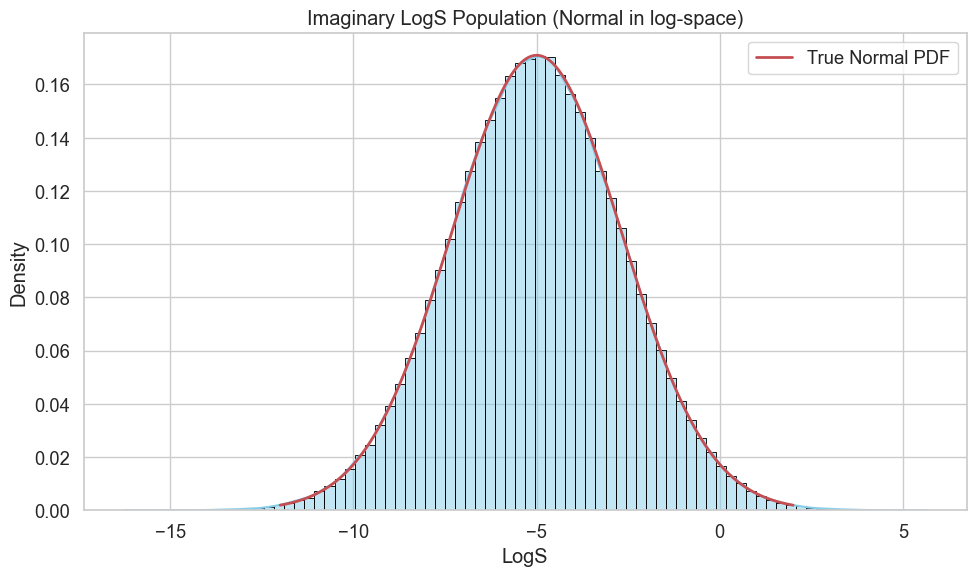

Real sample size: 1763, range: [-7.00, -2.82]
Restricted population size: 314263


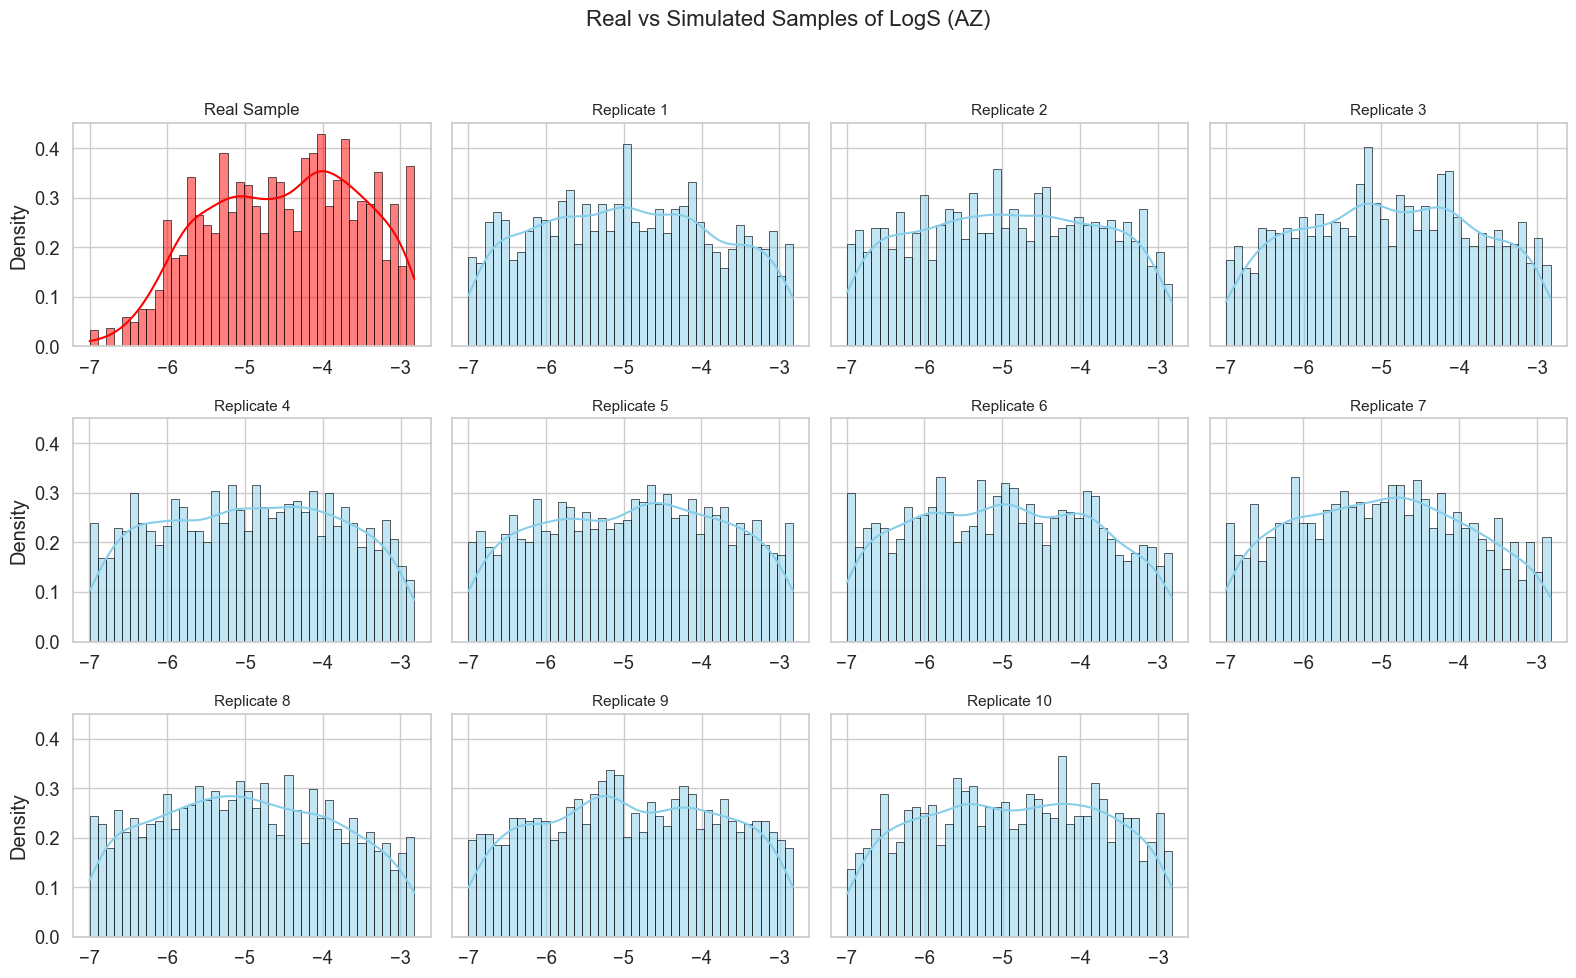

In [9]:
real_sample = df["LogS"].dropna().values
n_real = len(real_sample)

# -----------------------
# Step 1: Define imaginary LogS population
# -----------------------
low, high = -12, 2
mu = (low + high) / 2        # midpoint
sigma = (high - low) / 6     # so [low, high] ~ mu ± 3σ
print(f"Imaginary population ~ Normal(mu={mu:.2f}, sigma={sigma:.2f}) in LogS")

# -----------------------
# Step 2: Generate population & plot it
# -----------------------
pop_size = 500_000
population = np.random.normal(mu, sigma, size=pop_size)

plt.figure(figsize=(10, 6))
sns.histplot(population, bins=80, kde=True, stat="density", color="skyblue", edgecolor="black")
x = np.linspace(low, high, 1000)
plt.plot(x, norm.pdf(x, mu, sigma), "r-", lw=2, label="True Normal PDF")
plt.title("Imaginary LogS Population (Normal in log-space)")
plt.xlabel("LogS")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(images_dir, "imaginary_distribution.png"))
plt.show()

# -----------------------
# Step 3: Restrict to same range as real dataset
# -----------------------
range_low, range_high = real_sample.min(), real_sample.max()
restricted_pop = population[(population >= range_low) & (population <= range_high)]
print(f"Real sample size: {n_real}, range: [{range_low:.2f}, {range_high:.2f}]")
print(f"Restricted population size: {len(restricted_pop)}")

# -----------------------
# Step 4: Draw 10 random replicates of same size
# -----------------------
n_reps = 10
replicates = [np.random.choice(restricted_pop, size=n_real, replace=False)
              for _ in range(n_reps)]

# -----------------------
# Step 5: Plot real sample + replicates
# -----------------------
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=False, sharey=True)
axes = axes.flatten()

# Plot the real sample
sns.histplot(real_sample, bins=40, kde=True, color="red", edgecolor="black", ax=axes[0], stat="density")
axes[0].set_title("Real Sample", fontsize=12)

# Plot the replicates
for i, ax in enumerate(axes[1:1+len(replicates)]):
    sns.histplot(replicates[i], bins=40, kde=True, color="skyblue", edgecolor="black", ax=ax, stat="density")
    ax.set_title(f"Replicate {i+1}", fontsize=11)

# Hide unused axes (last subplot if grid > samples)
for ax in axes[1+len(replicates):]:
    ax.axis("off")

plt.suptitle(f"Real vs Simulated Samples of LogS ({DATASET_NAME})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(images_dir, "random_check.png"))
plt.show()


## Chemical inspection of "randomness"

While statistics can tell us if the "values" are diverse, this does not guarantee that the chemistry is diverse as well. many molecules can give different solubility values, yet share very similar structure that makes the sample clustered in a specific region in the chemical space.

Below we inspect the chemical diversity by checking the Murcko scaffolds diversity and coverage.

Verdict: The data is quite chemically diverse with respect to Murcko scaffolds

Total molecules: 1763
Molecules with valid scaffold: 1763
Unique scaffolds: 1067
Unique scaffolds as % of total molecules: 60.52%


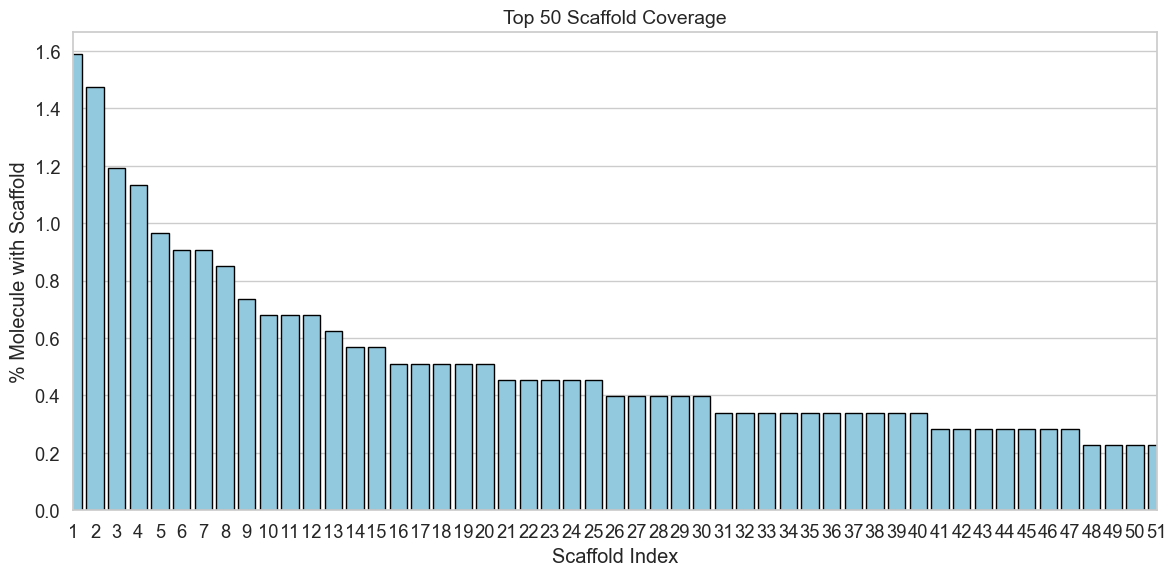

In [10]:
# ---- Step 1: Compute scaffolds from SMILES ----
def smiles_to_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

df["Scaffold"] = df["SMILES"].apply(smiles_to_scaffold)

# total molecules
total_mols = len(df)

# number of molecules with a valid scaffold
valid_mols = df["Scaffold"].notna().sum()

# number of unique scaffolds
unique_scaffolds = df["Scaffold"].nunique(dropna=True)

# percentage
percentage = (unique_scaffolds / total_mols) * 100

print(f"Total molecules: {total_mols}")
print(f"Molecules with valid scaffold: {valid_mols}")
print(f"Unique scaffolds: {unique_scaffolds}")
print(f"Unique scaffolds as % of total molecules: {percentage:.2f}%")


# ---- Step 2: Count molecules per scaffold ----
scaffold_counts = df["Scaffold"].value_counts().reset_index()
scaffold_counts.columns = ["Scaffold", "Count"]

# Compute percentage
total_molecules = scaffold_counts["Count"].sum()
scaffold_counts["Percent"] = (scaffold_counts["Count"] / total_molecules) * 100

# Assign index (1,2,3,...) for plotting instead of scaffold string
scaffold_counts["ScaffoldIdx"] = range(1, len(scaffold_counts) + 1)

# ---- Step 3: Plot percentage per scaffold index ----
plt.figure(figsize=(12, 6))
sns.barplot(
    x="ScaffoldIdx",
    y="Percent",
    data=scaffold_counts,
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Scaffold Index")
plt.ylabel("% Molecule with Scaffold")

# Optional: show only top N scaffolds if too many
top_k = 50
plt.xlim(0, top_k)   # e.g., zoom to first 50 scaffolds
plt.title(f"Top {top_k} Scaffold Coverage", fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "scaffolds_pct.png"))
plt.show()


Below we see the top 5 most common scaffolds and 5 molecules from each scaffold group

=== Scaffold 1 ===
SMILES: O=C(c1ccccc1)C1CCN(C(=O)c2ccccc2)CC1


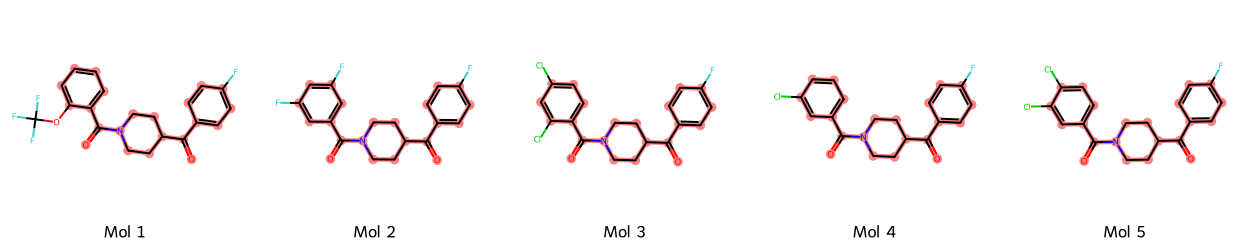

Saved: scaffold_1.png
=== Scaffold 2 ===
SMILES: c1ccc(Nc2nccc(-c3cnc[nH]3)n2)cc1


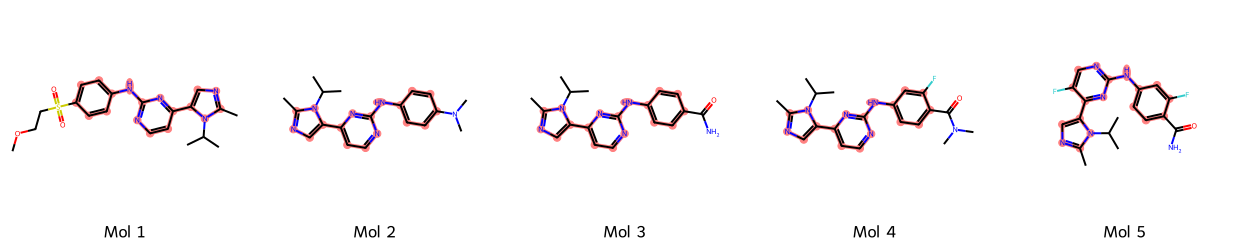

Saved: scaffold_2.png
=== Scaffold 3 ===
SMILES: c1ccc(Nc2ncnc3ccccc23)cc1


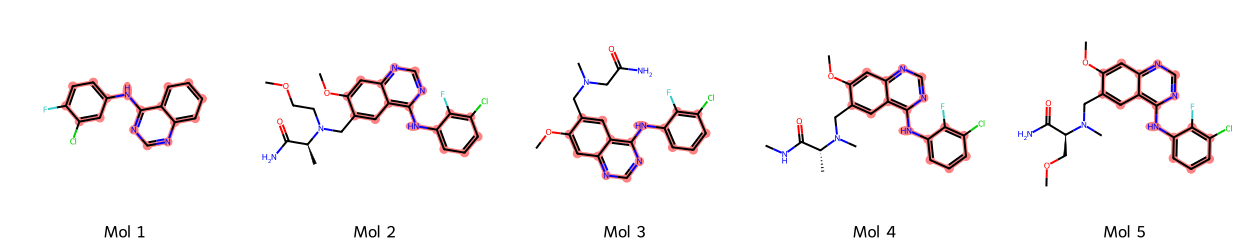

Saved: scaffold_3.png
=== Scaffold 4 ===
SMILES: O=C(Cc1ccccc1)NC1CCN(CCC(c2ccccc2)c2ccccc2)CC1


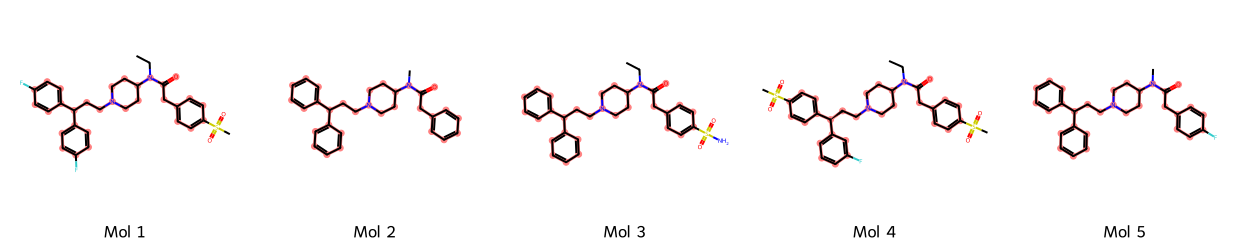

Saved: scaffold_4.png
=== Scaffold 5 ===
SMILES: O=C(NC1Cc2ccccc2NC1=O)c1cc2ccsc2[nH]1


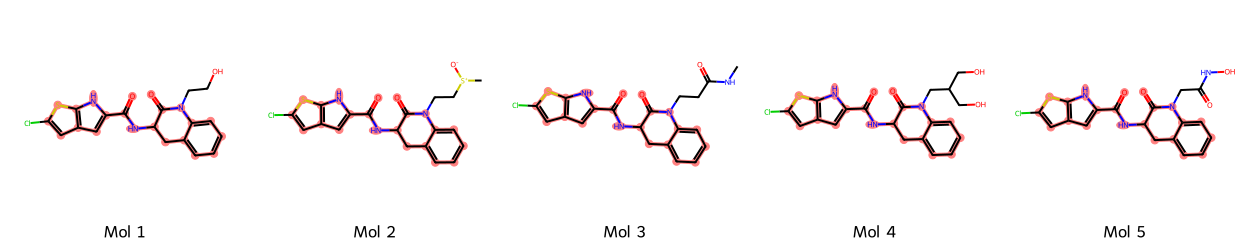

Saved: scaffold_5.png


In [11]:
top_n = 5

for idx in range(top_n):
    chosen_scaffold = scaffold_counts.loc[idx, "Scaffold"]
    print(f"=== Scaffold {idx+1} ===")
    print("SMILES:", chosen_scaffold)

    # Select up to 5 molecules with this scaffold
    example_smiles = df[df["Scaffold"] == chosen_scaffold]["SMILES"].head(5).tolist()

    # Convert scaffold and molecules
    scaffold_mol = Chem.MolFromSmiles(chosen_scaffold)
    mols = []
    highlight_atoms = []

    for smi in example_smiles:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            match = mol.GetSubstructMatch(scaffold_mol)
            mols.append(mol)
            highlight_atoms.append(match)

    # Draw molecules with scaffold highlighted
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(250, 250),
        highlightAtomLists=highlight_atoms,
        legends=[f"Mol {i+1}" for i in range(len(mols))],
        returnPNG=False   # For some reason, setting this parameter explicitly was crucial to be able to use the .save() function!
    )

    # Show in notebook
    display(img)

    # Save as PNG
    filename = f"scaffold_{idx+1}.png"
    img.save(os.path.join(images_dir, filename))
    print(f"Saved: {filename}")


Below we inspect the least common scaffolds (but since 60% of the scaffolds are unique, this does not rpresent "least" common per se, but rather a 10 examples of these 60%)

=== Least Frequent Scaffold 1 ===
SMILES: O=C(Nc1ccccc1)c1ccc(CNc2ccccc2)cc1
Count: 1 molecules


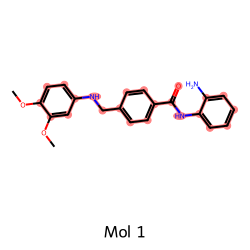

Saved: scaffold_least_1.png
=== Least Frequent Scaffold 2 ===
SMILES: c1ccc(CNCc2ccc(-c3cccs3)cc2)cc1
Count: 1 molecules


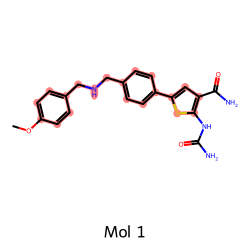

Saved: scaffold_least_2.png
=== Least Frequent Scaffold 3 ===
SMILES: O=c1ccc2cnc(Nc3ccccc3)nc2[nH]1
Count: 1 molecules


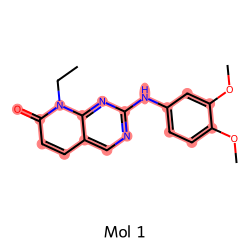

Saved: scaffold_least_3.png
=== Least Frequent Scaffold 4 ===
SMILES: c1ccc(-c2cc3ccccc3cn2)cc1
Count: 1 molecules


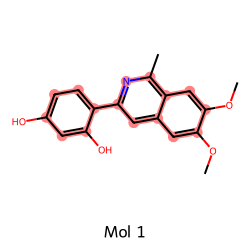

Saved: scaffold_least_4.png
=== Least Frequent Scaffold 5 ===
SMILES: O=C(Cc1ccc2[nH]c(-c3ccccc3)c(CCNCCc3ccc4[nH]nnc4c3)c2c1)N1CC2CCC1CC2
Count: 1 molecules


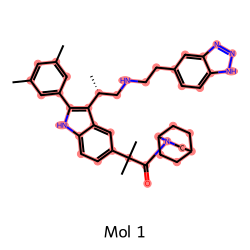

Saved: scaffold_least_5.png
=== Least Frequent Scaffold 6 ===
SMILES: O=S(=O)(c1ccccc1)c1cccc(C2CCOCC2)c1
Count: 1 molecules


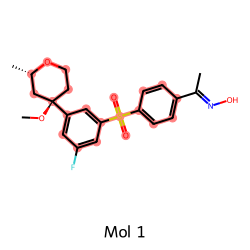

Saved: scaffold_least_6.png
=== Least Frequent Scaffold 7 ===
SMILES: C1=NN(c2ccccc2)CC1
Count: 1 molecules


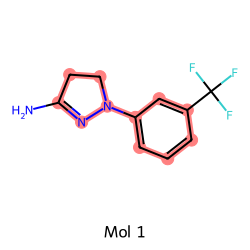

Saved: scaffold_least_7.png
=== Least Frequent Scaffold 8 ===
SMILES: c1ncc2c(n1)OCC(c1ccc(C34CC5CC(CC(C5)C3)C4)cc1)=N2
Count: 1 molecules


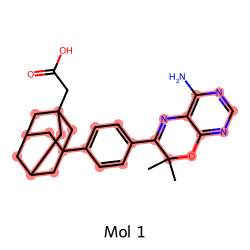

Saved: scaffold_least_8.png
=== Least Frequent Scaffold 9 ===
SMILES: O=S1(=O)CCC(n2cc(-c3ccccc3)cn2)C1
Count: 1 molecules


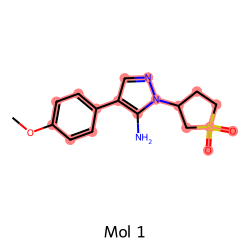

Saved: scaffold_least_9.png
=== Least Frequent Scaffold 10 ===
SMILES: O=C(Nc1ccc2[nH]c3ccccc3c2c1)N1CCCCC1
Count: 1 molecules


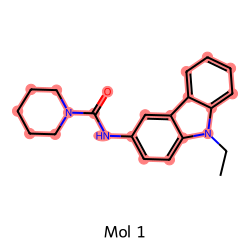

Saved: scaffold_least_10.png


In [12]:
# Get the 10 least frequent scaffolds
bottom_n = 10
least_common_scaffolds = scaffold_counts.sort_values("Count", ascending=True).head(bottom_n).reset_index(drop=True)

for idx, row in least_common_scaffolds.iterrows():
    chosen_scaffold = row["Scaffold"]
    print(f"=== Least Frequent Scaffold {idx+1} ===")
    print("SMILES:", chosen_scaffold)
    print(f"Count: {row['Count']} molecules")

    # Select up to 5 molecules with this scaffold
    example_smiles = df[df["Scaffold"] == chosen_scaffold]["SMILES"].head(5).tolist()

    # Convert scaffold and molecules
    scaffold_mol = Chem.MolFromSmiles(chosen_scaffold)
    mols = []
    highlight_atoms = []

    for smi in example_smiles:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            match = mol.GetSubstructMatch(scaffold_mol)
            mols.append(mol)
            highlight_atoms.append(list(match))

    if not mols:
        continue

    # ---- Dynamic grid size ----
    n_mols = len(mols)
    mols_per_row = min(n_mols, 5)  # max 5 per row
    n_rows = math.ceil(n_mols / mols_per_row)
    sub_img_size = (250, 250)

    # Draw molecules with scaffold highlighted
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=mols_per_row,
        subImgSize=sub_img_size,
        highlightAtomLists=highlight_atoms,
        legends=[f"Mol {i+1}" for i in range(len(mols))],
        returnPNG=False
    )

    # Show in notebook
    display(img)

    # Save as PNG
    filename = f"scaffold_least_{idx+1}.png"
    img.save(os.path.join(images_dir, filename))
    print(f"Saved: {filename}")
